# AutoML for Vishing Detection — AutoGluon Tabular

## Objective

Determine the best binary classification model to distinguish vishing sessions (`is_vishing=1`) from legitimate sessions (`is_vishing=0`), using the CTGAN-augmented synthetic dataset (1M mobile sessions, ~1.5% vishing rate).

## Methodological decisions

| Aspect | Decision |
|---|---|
| Framework | AutoGluon Tabular with `presets='best_quality'` |
| Primary metric | PR-AUC (`average_precision`) |
| Secondary metrics | Recall @ precision=0.90, Recall @ precision=0.95, ROC-AUC, F1 |
| Split | Train on the mixed 1M (originals + synthetics). Val and test **on originals only** — answers "does it generalize to real data?" |
| Excluded features | IDs, timestamps, device/app metadata, simulated BioCatch scores, claim labels |
| Time budget | 5400 s (90 min) |
| S3 artifacts | Predictor, leaderboard, plots, metrics and config in timestamped folders |

## Winning-model analysis

- Confusion matrices at the optimal (max F1) threshold and at the operational threshold (precision=0.90).
- PR curve and ROC curve with bootstrap confidence intervals.
- Permutation-based feature importance (more honest than the model's native importance).
- Calibration plot and Brier score.
- SHAP summary and dependence plots on the top-5 features.
- Error breakdown by hour of day and session-duration decile.
- Sanity check: performance on originals vs. synthetics inside the test set.


## 0. Setup and imports

In [1]:
import boto3
import sagemaker
import json
import os
import time
import warnings
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                              precision_recall_curve, roc_curve, confusion_matrix,
                              brier_score_loss, precision_score, recall_score)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

from autogluon.tabular import TabularDataset, TabularPredictor
import shap

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6), 'font.size': 11, 'axes.titlesize': 14,
    'axes.labelsize': 12, 'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = {'legit': '#2ecc71', 'vishing': '#e74c3c', 'neutral': '#3498db',
          'ours': '#9b59b6', 'baseline': '#95a5a6'}

SEED = 42
np.random.seed(SEED)

# SageMaker session
sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
S3_BUCKET = 'poc-fraude-vishing'

# Unique timestamp to version all artifacts of this run
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f'Run ID: {RUN_ID}')
print(f'S3 bucket: {S3_BUCKET}')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


/home/ec2-user/SageMaker/Vishing_synth_data_GenAI/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run ID: 20260708_235112
S3 bucket: poc-fraude-vishing


## 1. Load the augmented dataset

We load the parquet produced by notebook 4b (CTGAN). The `is_synthetic` column is critical: we use it to define the split, but **we exclude it as a feature** so the model does not learn to distinguish originals from synthetics.

In [2]:
AUGMENTED_DATA_PATH = 's3://poc-fraude-vishing/data/augmented/dataset_1M_vishing_ctgan.parquet'

t0 = time.time()
df = pd.read_parquet(AUGMENTED_DATA_PATH)
print(f'Loaded {len(df):,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s')

print(f'\nClass balance:')
print(df['is_vishing'].value_counts(normalize=True).apply(lambda x: f'{x*100:.3f}%'))
print(f'\nSynthetic vs original:')
print(df['is_synthetic'].value_counts(normalize=True).apply(lambda x: f'{x*100:.3f}%'))
print(f'\nOriginals per class:')
print(df[df['is_synthetic']==0]['is_vishing'].value_counts())

Loaded 1,000,000 rows x 62 cols in 1.7s

Class balance:
is_vishing
0    98.500%
1     1.500%
Name: proportion, dtype: object

Synthetic vs original:
is_synthetic
1    95.742%
0     4.258%
Name: proportion, dtype: object

Originals per class:
is_vishing
0    40452
1     2127
Name: count, dtype: int64


## 2. Feature selection and column drops

We exclude identifiers, timestamps, simulated BioCatch scores (to avoid leakage — the goal is to prove that our own signals classify well), claim metadata (post-hoc, not available at scoring time), and device/app metadata.

In [3]:
cols_to_drop = [
    'session_id', 'customer_id', 'session_timestamp',
    'biocatch_risk_score', 'biocatch_genuine_score',
    'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator',
    'days_to_claim', 'claim_category',
    'os_type', 'app_version', 'device_type', 'screens_visited','unusual_screen_visits', 'interactions_per_s'
]

TARGET = 'is_vishing'
SPLIT_MARKER = 'is_synthetic'   # used only for splitting, not as a feature

df_model = df.drop(columns=cols_to_drop).copy()
feature_cols = [c for c in df_model.columns if c not in (TARGET, SPLIT_MARKER)]

print(f'Total columns after drop: {df_model.shape[1]}')
print(f'Features for modeling:   {len(feature_cols)}')
print(f'\nFeatures ({len(feature_cols)}):')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')

Total columns after drop: 46
Features for modeling:   44

Features (44):
   1. avg_keyhold_ms
   2. avg_interkey_latency_ms
   3. typing_speed_cps
   4. keystroke_variability
   5. segmented_typing_ratio
   6. avg_touch_pressure
   7. avg_touch_size_px
   8. swipe_speed_px_s
   9. swipe_directional_variance
  10. scroll_speed_avg
  11. device_tilt_angle_mean
  12. device_tilt_variability
  13. gyro_rotation_rate_mean
  14. accelerometer_jerk_mean
  15. avg_hesitation_duration_s
  16. max_hesitation_duration_s
  17. total_dead_time_s
  18. dead_time_ratio
  19. screen_transition_time_avg_s
  20. data_familiarity_score
  21. session_duration_s
  22. call_overlap_duration_s
  23. time_to_transaction_s
  24. phone_motion_events
  25. hesitation_count
  26. dead_time_periods
  27. unique_screens_visited
  28. navigation_back_count
  29. input_error_count
  30. input_correction_count
  31. amount_field_corrections
  32. beneficiary_field_corrections
  33. copy_paste_events
  34. doodling_eve

## 3. Split — mixed train, val and test on originals only

This is the decision that **defines the credibility of the PoC**. The model is trained on the full augmented pool (1M rows), but is validated and tested exclusively on the real sessions of the original dataset. That way we answer the question: *"does a model trained on augmented data generalize to real data?"*

In [4]:
# 1. Separate originals from synthetics
df_originals = df_model[df_model[SPLIT_MARKER] == 0].copy().reset_index(drop=True)
df_synthetic = df_model[df_model[SPLIT_MARKER] == 1].copy().reset_index(drop=True)

print(f'Originals: {len(df_originals):,} (vishing: {df_originals[TARGET].sum():,})')
print(f'Synthetics: {len(df_synthetic):,} (vishing: {df_synthetic[TARGET].sum():,})')

# 2. On originals: stratified 40/30/30 split
df_orig_train, df_orig_temp = train_test_split(
    df_originals, test_size=0.60, stratify=df_originals[TARGET], random_state=SEED)
df_orig_val, df_orig_test = train_test_split(
    df_orig_temp, test_size=0.50, stratify=df_orig_temp[TARGET], random_state=SEED)

print(f'\nOriginals split (40/30/30):')
print(f'  train:  {len(df_orig_train):>6,} (vishing: {df_orig_train[TARGET].sum():,})')
print(f'  val:    {len(df_orig_val):>6,} (vishing: {df_orig_val[TARGET].sum():,})')
print(f'  test:   {len(df_orig_test):>6,} (vishing: {df_orig_test[TARGET].sum():,})')

# 3. TRAIN = 40% of originals + ALL synthetics
df_train = pd.concat([df_orig_train, df_synthetic], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 4. VAL and TEST are originals only
df_val = df_orig_val.reset_index(drop=True)
df_test = df_orig_test.reset_index(drop=True)

# 5. Drop the split marker so the model never sees it
for d in [df_train, df_val, df_test]:
    d.drop(columns=[SPLIT_MARKER], inplace=True, errors='ignore')

print(f'\nFINAL SPLIT:')
print(f'  TRAIN (mixed):    {len(df_train):>8,} rows  |  vishing rate: {df_train[TARGET].mean()*100:.3f}%')
print(f'  VAL (originals):  {len(df_val):>8,} rows  |  vishing rate: {df_val[TARGET].mean()*100:.3f}%')
print(f'  TEST (originals): {len(df_test):>8,} rows  |  vishing rate: {df_test[TARGET].mean()*100:.3f}%')

Originals: 42,579 (vishing: 2,127)
Synthetics: 957,421 (vishing: 12,873)

Originals split (40/30/30):
  train:  17,031 (vishing: 851)
  val:    12,774 (vishing: 638)
  test:   12,774 (vishing: 638)

FINAL SPLIT:
  TRAIN (mixed):     974,452 rows  |  vishing rate: 1.408%
  VAL (originals):    12,774 rows  |  vishing rate: 4.995%
  TEST (originals):   12,774 rows  |  vishing rate: 4.995%


## 4. AutoGluon training

- `eval_metric='average_precision'` optimizes PR-AUC directly.
- `presets='best_quality'` enables multi-level stacking, bagging, and hyperparameter search.
- `time_limit=5400` (90 min) as the budget cap.
- The predictor is saved to a local directory versioned by `RUN_ID`, then uploaded to S3.

In [5]:
import shutil

# Nuevo RUN_ID y directorio limpio
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
LOCAL_MODEL_DIR = f'automl_runs/{RUN_ID}/predictor'

if Path(LOCAL_MODEL_DIR).exists():
    shutil.rmtree(LOCAL_MODEL_DIR)
Path(LOCAL_MODEL_DIR).mkdir(parents=True, exist_ok=True)

predictor = TabularPredictor(
    label=TARGET,
    path=LOCAL_MODEL_DIR,
    eval_metric='average_precision',
    problem_type='binary',
    verbosity=2,
)

TIME_LIMIT = 5400

print(f'Run ID: {RUN_ID}')
print(f'Training AutoGluon best_quality with time_limit={TIME_LIMIT}s...')
t0 = time.time()

predictor.fit(
    train_data=TabularDataset(df_train),
    tuning_data=TabularDataset(df_val),
    use_bag_holdout=True,                # ← FIX: preserva val como holdout real en bagged mode
    presets='best_quality',
    time_limit=TIME_LIMIT,
    num_gpus=1,                          # tu instance tiene 1 GPU T4
    num_cpus=8,
)

elapsed = time.time() - t0
print(f'\nTraining done in {elapsed/60:.1f} min')

Verbosity: 2 (Standard Logging)


Run ID: 20260708_235116
Training AutoGluon best_quality with time_limit=5400s...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.20
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Tue Jun 16 23:32:44 UTC 2026
CPU Count:          8
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       15.42 GB / 30.98 GB (49.8%)
Disk Space Avail:   9.25 GB / 24.44 GB (37.8%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 5400


Training done in 90.0 min


## 5. Leaderboard and model comparison

In [6]:
leaderboard = predictor.leaderboard(TabularDataset(df_test), silent=True)
leaderboard = leaderboard.sort_values('score_test', ascending=False).reset_index(drop=True)

print('=== LEADERBOARD (score_test = PR-AUC on test set) ===\n')
display_cols = ['model', 'score_test', 'score_val', 'pred_time_test',
                'fit_time', 'stack_level']
print(leaderboard[display_cols].to_string(index=False))

=== LEADERBOARD (score_test = PR-AUC on test set) ===

                  model  score_test  score_val  pred_time_test    fit_time  stack_level
    WeightedEnsemble_L3    0.107581   0.099969       17.280570 4122.410327            3
        CatBoost_BAG_L2    0.107486   0.096930       16.544998 3978.426554            2
        LightGBM_BAG_L2    0.106288   0.095428       16.510115 3496.003218            2
    WeightedEnsemble_L2    0.104889   0.099486        5.461654 1493.562025            2
        LightGBM_BAG_L1    0.104299   0.094836        4.578768  767.874829            1
      LightGBMXT_BAG_L2    0.103976   0.095427       16.634679 3522.154561            2
        CatBoost_BAG_L1    0.103515   0.093204        0.089061  118.743733            1
  ExtraTreesGini_BAG_L2    0.103108   0.092213       17.115603 3582.765122            2
      LightGBMXT_BAG_L1    0.102099   0.092586       10.021167 1638.661954            1
RandomForestEntr_BAG_L2    0.101522   0.092390       16.722350 37

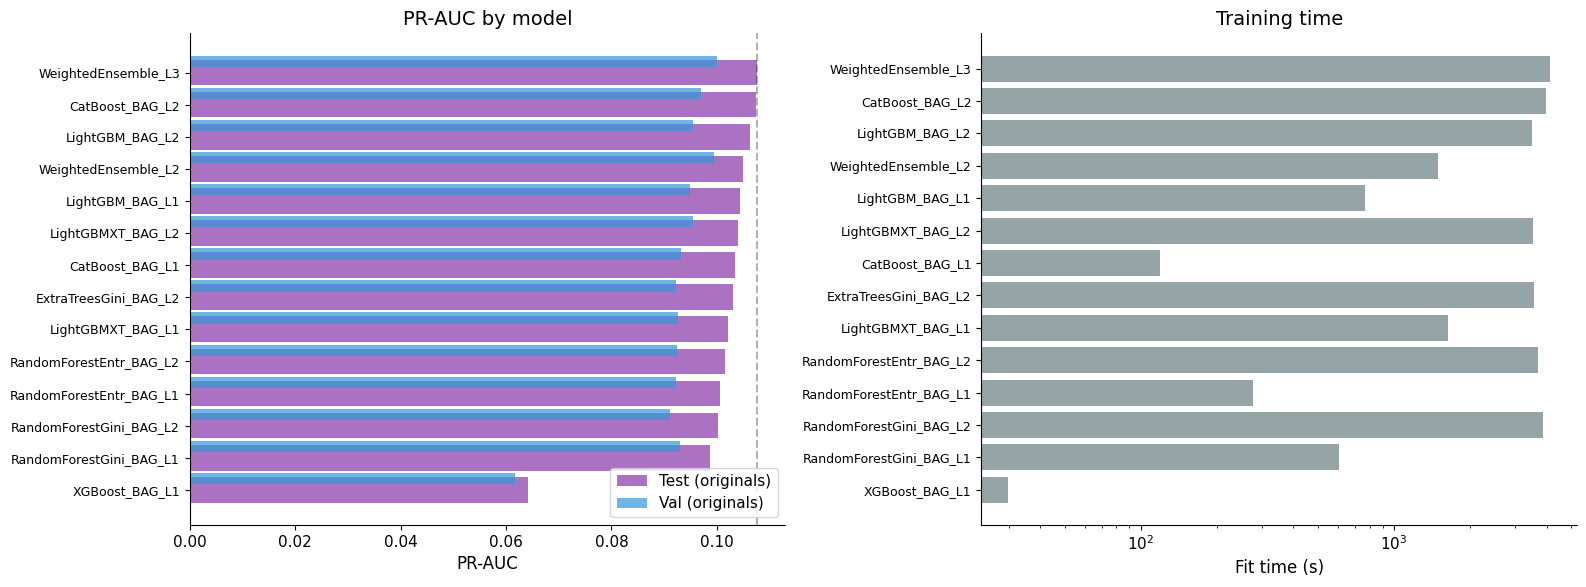

In [7]:
# Leaderboard visualization
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(leaderboard)*0.35)))

# PR-AUC test vs val
lb = leaderboard.copy()
y_pos = np.arange(len(lb))
axes[0].barh(y_pos, lb['score_test'], color=COLORS['ours'], alpha=0.85, label='Test (originals)')
axes[0].barh(y_pos - 0.35, lb['score_val'], height=0.35, color=COLORS['neutral'],
             alpha=0.7, label='Val (originals)')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(lb['model'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('PR-AUC')
axes[0].set_title('PR-AUC by model')
axes[0].legend(loc='lower right')
axes[0].axvline(lb['score_test'].max(), ls='--', color='k', alpha=0.3)

# Fit time
axes[1].barh(y_pos, lb['fit_time'], color=COLORS['baseline'])
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(lb['model'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Fit time (s)')
axes[1].set_title('Training time')
axes[1].set_xscale('log')

plt.tight_layout()
LEADERBOARD_PLOT = f'automl_runs/{RUN_ID}/reports/leaderboard.png'
Path(LEADERBOARD_PLOT).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(LEADERBOARD_PLOT, dpi=120, bbox_inches='tight')
plt.show()

## 6. Extended per-model metrics (recall @ fixed precision)

AutoGluon reports PR-AUC. We add the operational metrics that matter for the business: recall under a high-precision constraint (fewer false positives = less friction for legitimate customers).

In [8]:
def recall_at_precision(y_true, y_score, target_precision):
    """Return the maximum recall achievable under precision >= target."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
    mask = precisions >= target_precision
    if not mask.any():
        return 0.0, None
    valid_recalls = recalls[mask]
    valid_precisions = precisions[mask]
    idx = valid_recalls.argmax()
    # thresholds has length len(precisions)-1
    valid_thresholds = np.append(thresholds, 1.0)[mask]
    return float(valid_recalls[idx]), float(valid_thresholds[idx])


def full_metrics(y_true, y_score):
    return {
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'recall_at_p90': recall_at_precision(y_true, y_score, 0.90)[0],
        'recall_at_p95': recall_at_precision(y_true, y_score, 0.95)[0],
        'brier': float(brier_score_loss(y_true, y_score)),
    }


y_test = df_test[TARGET].values
extra_metrics = []

for model_name in leaderboard['model']:
    y_proba = predictor.predict_proba(df_test.drop(columns=[TARGET]),
                                       model=model_name).iloc[:, 1].values
    m = full_metrics(y_test, y_proba)
    m['model'] = model_name
    extra_metrics.append(m)

df_metrics = pd.DataFrame(extra_metrics).set_index('model')
df_metrics = df_metrics.sort_values('pr_auc', ascending=False)

print('=== EXTENDED METRICS ON TEST (originals only) ===\n')
print(df_metrics.round(4).to_string())

=== EXTENDED METRICS ON TEST (originals only) ===

                         pr_auc  roc_auc  recall_at_p90  recall_at_p95   brier
model                                                                         
WeightedEnsemble_L3      0.1076   0.6667         0.0000         0.0000  0.0567
CatBoost_BAG_L2          0.1075   0.6704         0.0000         0.0000  0.0613
LightGBM_BAG_L2          0.1063   0.6694         0.0000         0.0000  0.0618
WeightedEnsemble_L2      0.1049   0.6632         0.0000         0.0000  0.0542
LightGBM_BAG_L1          0.1043   0.6691         0.0000         0.0000  0.0594
LightGBMXT_BAG_L2        0.1040   0.6680         0.0016         0.0016  0.0634
CatBoost_BAG_L1          0.1035   0.6625         0.0000         0.0000  0.0537
ExtraTreesGini_BAG_L2    0.1031   0.6607         0.0016         0.0016  0.0602
LightGBMXT_BAG_L1        0.1021   0.6719         0.0000         0.0000  0.0607
RandomForestEntr_BAG_L2  0.1015   0.6529         0.0016         0.0016  0.0616
R

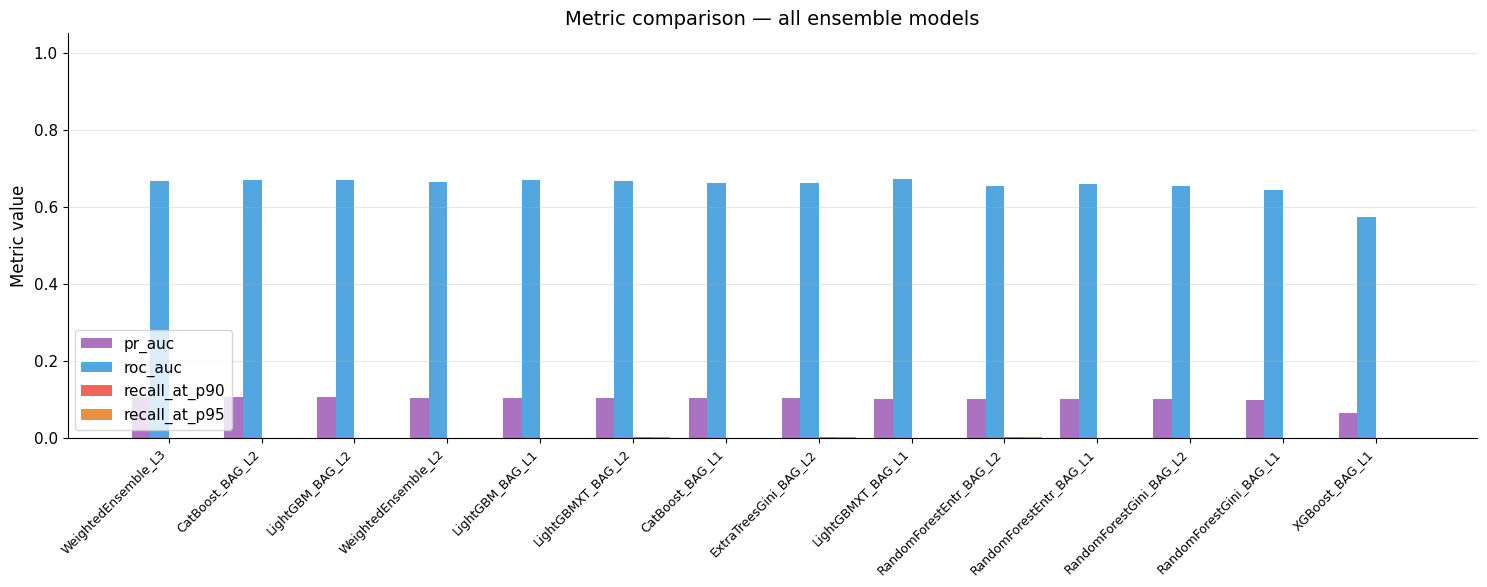

In [9]:
# Comparative visualization
fig, ax = plt.subplots(figsize=(15, max(6, len(df_metrics)*0.4)))

metrics_to_plot = ['pr_auc', 'roc_auc', 'recall_at_p90', 'recall_at_p95']
metric_colors = ['#9b59b6', '#3498db', '#e74c3c', '#e67e22']

x = np.arange(len(df_metrics))
w = 0.2
for i, (m, c) in enumerate(zip(metrics_to_plot, metric_colors)):
    ax.bar(x + i*w, df_metrics[m], w, label=m, color=c, alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(df_metrics.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Metric value')
ax.set_title('Metric comparison — all ensemble models')
ax.legend(loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
METRICS_PLOT = f'automl_runs/{RUN_ID}/reports/model_metrics_comparison.png'
plt.savefig(METRICS_PLOT, dpi=120, bbox_inches='tight')
plt.show()

## 7. Winning model — deep dive

The model with the highest PR-AUC on test becomes the "winning model". All the analysis below applies to it.

In [10]:
BEST_MODEL = df_metrics.index[0]
print(f'Best model: {BEST_MODEL}')
print(f'   PR-AUC test:      {df_metrics.loc[BEST_MODEL, "pr_auc"]:.4f}')
print(f'   ROC-AUC test:     {df_metrics.loc[BEST_MODEL, "roc_auc"]:.4f}')
print(f'   Recall @ p=0.90:  {df_metrics.loc[BEST_MODEL, "recall_at_p90"]:.4f}')
print(f'   Recall @ p=0.95:  {df_metrics.loc[BEST_MODEL, "recall_at_p95"]:.4f}')
print(f'   Brier score:      {df_metrics.loc[BEST_MODEL, "brier"]:.4f}')

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET].values
y_proba_best = predictor.predict_proba(X_test, model=BEST_MODEL).iloc[:, 1].values

Best model: WeightedEnsemble_L3
   PR-AUC test:      0.1076
   ROC-AUC test:     0.6667
   Recall @ p=0.90:  0.0000
   Recall @ p=0.95:  0.0000
   Brier score:      0.0567


### 7.1 Threshold selection

Two thresholds relevant for banking:

- **Optimal F1 threshold**: neutral precision-recall balance, useful for technical validation.
- **Operational threshold (precision=0.90)**: under this constraint, 9 out of 10 alerts are real. This is what a fraud operations center can run without saturating analysts.

In [11]:
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_f1_idx = f1_scores.argmax()
THRESHOLD_F1 = float(thresholds_pr[min(best_f1_idx, len(thresholds_pr)-1)])

# Operational thresholds
_, THRESHOLD_P90 = recall_at_precision(y_test, y_proba_best, 0.90)
_, THRESHOLD_P95 = recall_at_precision(y_test, y_proba_best, 0.95)

print(f'Threshold @ max F1:         {THRESHOLD_F1:.4f}')
print(f'Threshold @ precision=0.90: {THRESHOLD_P90}')
print(f'Threshold @ precision=0.95: {THRESHOLD_P95}')

Threshold @ max F1:         0.1680
Threshold @ precision=0.90: 1.0
Threshold @ precision=0.95: 1.0


### 7.2 Confusion matrices at both thresholds

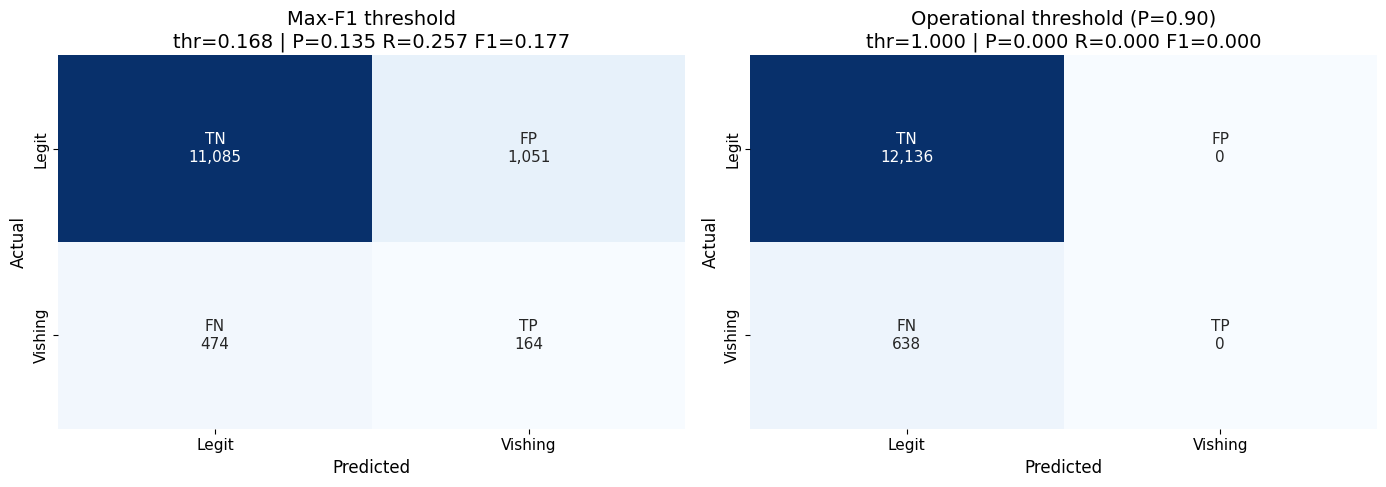

In [12]:
def confusion_at_threshold(y_true, y_proba, threshold, ax, title):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    labels = np.array([[f'TN\n{cm[0,0]:,}', f'FP\n{cm[0,1]:,}'],
                       [f'FN\n{cm[1,0]:,}', f'TP\n{cm[1,1]:,}']])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Legit', 'Vishing'], yticklabels=['Legit', 'Vishing'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nthr={threshold:.3f} | P={p:.3f} R={r:.3f} F1={f1:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if THRESHOLD_P90 is not None:
    confusion_at_threshold(y_test, y_proba_best, THRESHOLD_F1, axes[0], 'Max-F1 threshold')
    confusion_at_threshold(y_test, y_proba_best, THRESHOLD_P90, axes[1], 'Operational threshold (P=0.90)')
else:
    confusion_at_threshold(y_test, y_proba_best, THRESHOLD_F1, axes[0], 'Max-F1 threshold')
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'No threshold reaches\nprecision=0.90',
                 ha='center', va='center', fontsize=13)
plt.tight_layout()
CM_PLOT = f'automl_runs/{RUN_ID}/reports/confusion_matrices.png'
plt.savefig(CM_PLOT, dpi=120, bbox_inches='tight')
plt.show()

### 7.3 PR curve and ROC curve with bootstrap confidence intervals

500 bootstrap replicates to obtain 95% CIs for PR-AUC and ROC-AUC. Gives us a magnitude of the uncertainty around our point estimates.

Running 500 bootstraps for CI...
PR-AUC:  0.1099 [95% CI: 0.0942 - 0.1301]
ROC-AUC: 0.6669 [95% CI: 0.6449 - 0.6888]


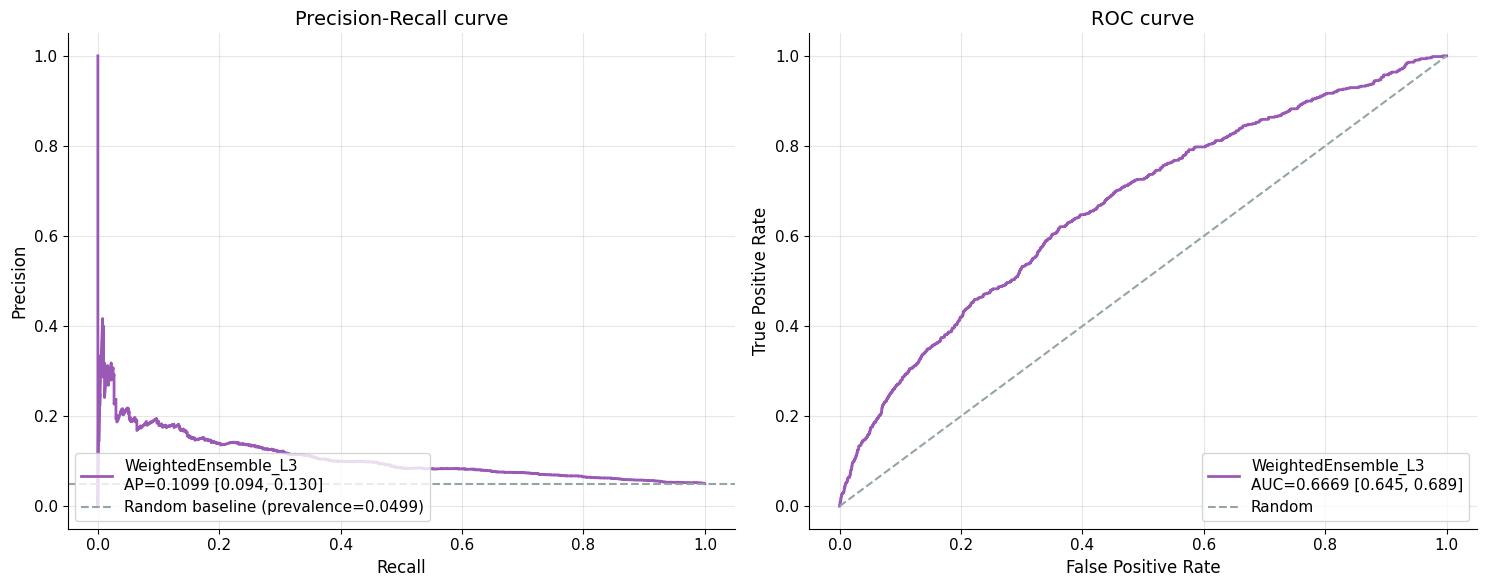

In [13]:
def bootstrap_curves(y_true, y_score, n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    pr_aucs, roc_aucs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:   # skip if the bootstrap draws a single class
            continue
        pr_aucs.append(average_precision_score(y_true[idx], y_score[idx]))
        roc_aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    return np.array(pr_aucs), np.array(roc_aucs)

print('Running 500 bootstraps for CI...')
pr_boot, roc_boot = bootstrap_curves(y_test, y_proba_best, n_boot=500)
pr_ci = (np.percentile(pr_boot, 2.5), np.percentile(pr_boot, 97.5))
roc_ci = (np.percentile(roc_boot, 2.5), np.percentile(roc_boot, 97.5))

print(f'PR-AUC:  {pr_boot.mean():.4f} [95% CI: {pr_ci[0]:.4f} - {pr_ci[1]:.4f}]')
print(f'ROC-AUC: {roc_boot.mean():.4f} [95% CI: {roc_ci[0]:.4f} - {roc_ci[1]:.4f}]')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PR
axes[0].plot(recalls, precisions, color=COLORS['ours'], lw=2,
             label=f'{BEST_MODEL}\nAP={pr_boot.mean():.4f} [{pr_ci[0]:.3f}, {pr_ci[1]:.3f}]')
axes[0].axhline(y_test.mean(), ls='--', color=COLORS['baseline'],
                label=f'Random baseline (prevalence={y_test.mean():.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall curve')
axes[0].legend(loc='lower left')
axes[0].grid(alpha=0.3)

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[1].plot(fpr, tpr, color=COLORS['ours'], lw=2,
             label=f'{BEST_MODEL}\nAUC={roc_boot.mean():.4f} [{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]')
axes[1].plot([0,1], [0,1], ls='--', color=COLORS['baseline'], label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
CURVES_PLOT = f'automl_runs/{RUN_ID}/reports/pr_roc_curves.png'
plt.savefig(CURVES_PLOT, dpi=120, bbox_inches='tight')
plt.show()

### 7.4 Permutation feature importance

AutoGluon's native importance can be biased by scale and cardinality. **Permutation importance** is more honest: it measures how much the metric drops when a feature is randomly shuffled. AutoGluon ships an integrated implementation.

These features in provided data are not utilized by the predictor and will be ignored: ['session_duration_s']
Computing feature importance via permutation shuffling for 43 features using 10000 rows with 5 shuffle sets...


Computing permutation importance on test set (may take a couple of minutes)...


	3082.21s	= Expected runtime (616.44s per shuffle set)
	2544.34s	= Actual runtime (Completed 5 of 5 shuffle sets)


  Done in 2544.4s


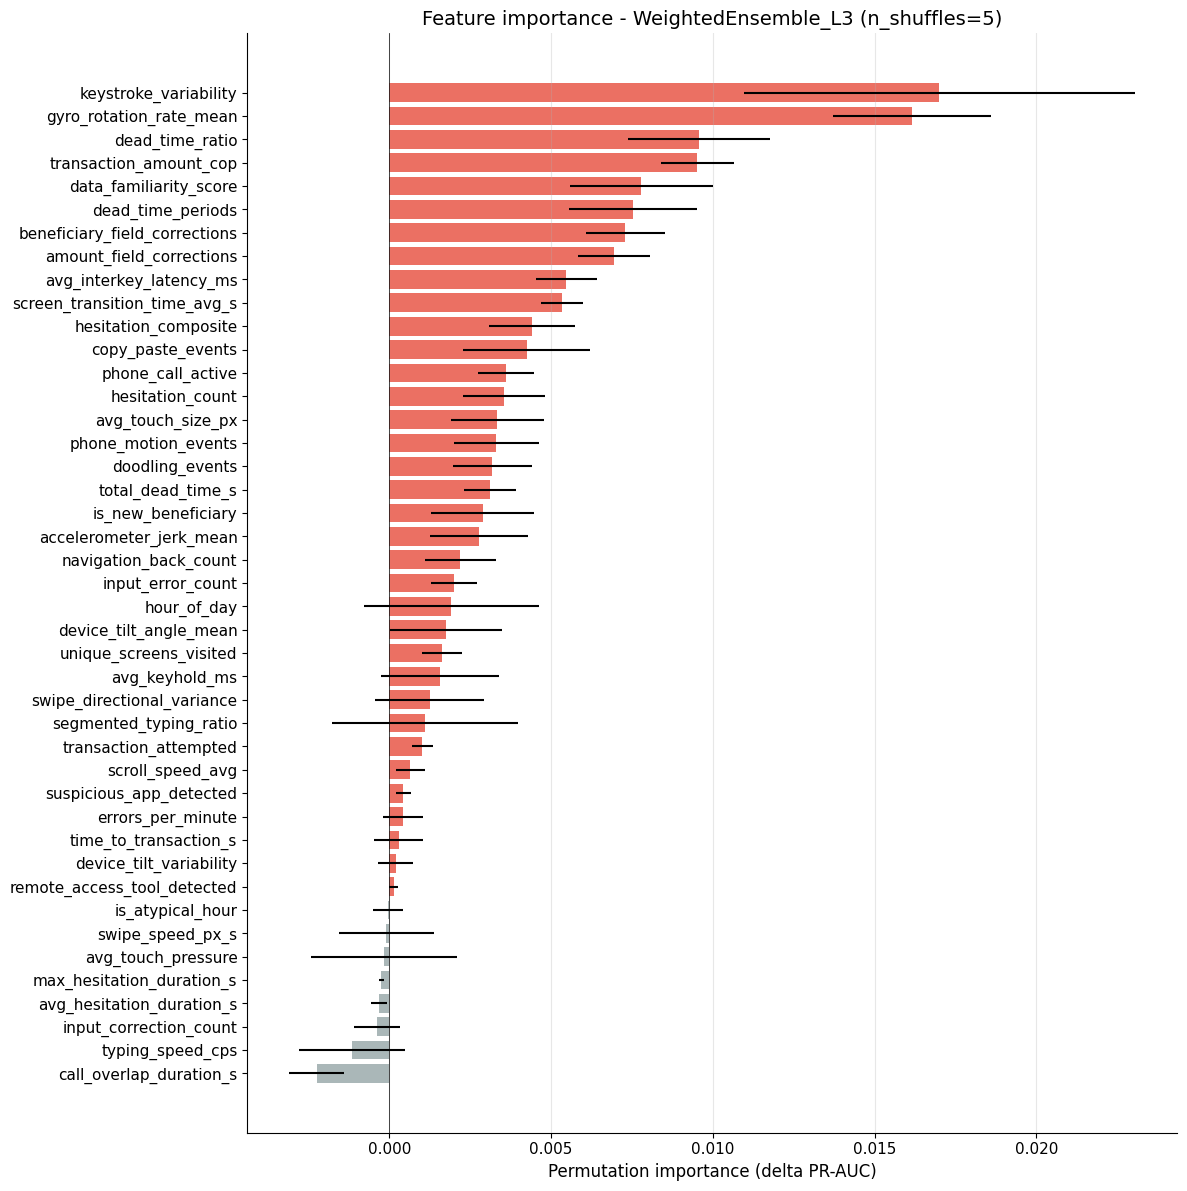


Top 10 features:
                               importance  stddev  p_value  n  p99_high  p99_low
keystroke_variability              0.0170  0.0060   0.0016  5    0.0294   0.0046
gyro_rotation_rate_mean            0.0162  0.0025   0.0001  5    0.0212   0.0111
dead_time_ratio                    0.0096  0.0022   0.0003  5    0.0141   0.0050
transaction_amount_cop             0.0095  0.0011   0.0000  5    0.0118   0.0072
data_familiarity_score             0.0078  0.0022   0.0007  5    0.0123   0.0032
dead_time_periods                  0.0075  0.0020   0.0005  5    0.0116   0.0035
beneficiary_field_corrections      0.0073  0.0012   0.0001  5    0.0098   0.0048
amount_field_corrections           0.0069  0.0011   0.0001  5    0.0092   0.0047
avg_interkey_latency_ms            0.0055  0.0010   0.0001  5    0.0074   0.0035
screen_transition_time_avg_s       0.0053  0.0007   0.0000  5    0.0067   0.0040


In [14]:
print('Computing permutation importance on test set (may take a couple of minutes)...')
t0 = time.time()
feat_imp = predictor.feature_importance(
    data=TabularDataset(df_test),
    model=BEST_MODEL,
    num_shuffle_sets=5,
    subsample_size=min(10_000, len(df_test)),
)
print(f'  Done in {time.time()-t0:.1f}s')

feat_imp_sorted = feat_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(feat_imp)*0.28)))
colors_bars = [COLORS['vishing'] if v > 0 else COLORS['baseline']
               for v in feat_imp_sorted['importance']]
ax.barh(feat_imp_sorted.index, feat_imp_sorted['importance'],
        xerr=feat_imp_sorted['stddev'], color=colors_bars, alpha=0.8)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Permutation importance (delta PR-AUC)')
ax.set_title(f'Feature importance - {BEST_MODEL} (n_shuffles=5)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
FIMP_PLOT = f'automl_runs/{RUN_ID}/reports/feature_importance.png'
plt.savefig(FIMP_PLOT, dpi=120, bbox_inches='tight')
plt.show()

print(f'\nTop 10 features:')
print(feat_imp.head(10).round(4).to_string())

### 7.5 Calibration plot and Brier score

A well-calibrated model means that when it says "probability 0.8", the empirical frequency of the positive class is close to 0.8. Critical for banking: the fraud operator uses the score as a probability, not merely as a ranking.

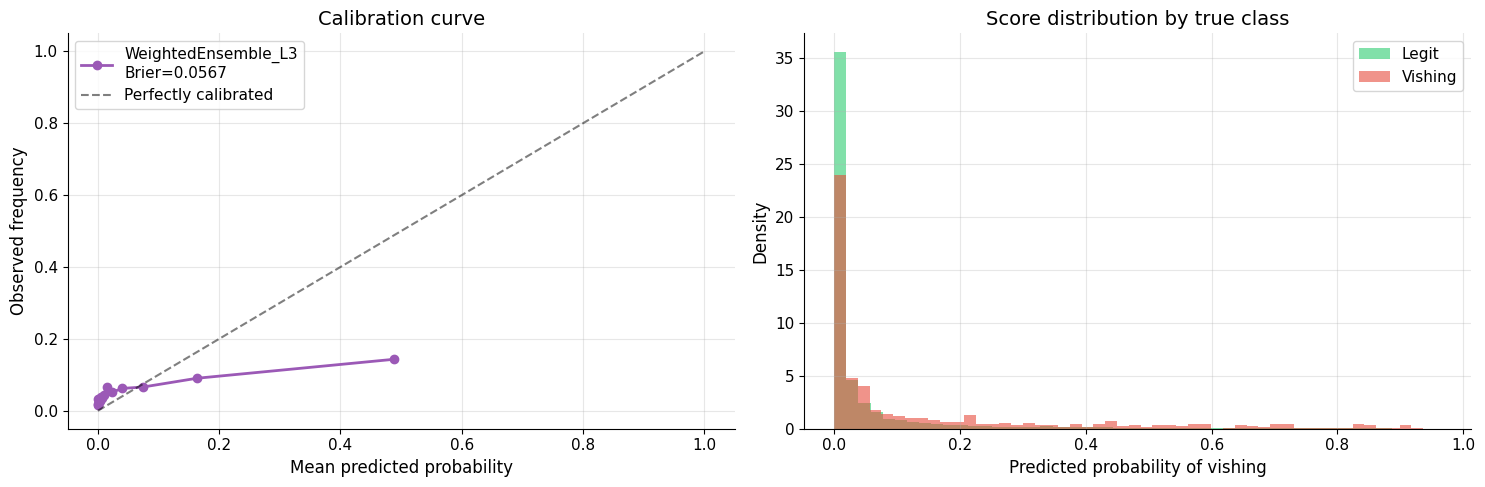

In [15]:
prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=15, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Calibration
axes[0].plot(prob_pred, prob_true, marker='o', lw=2, color=COLORS['ours'],
             label=f'{BEST_MODEL}\nBrier={df_metrics.loc[BEST_MODEL, "brier"]:.4f}')
axes[0].plot([0,1], [0,1], ls='--', color='k', alpha=0.5, label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Observed frequency')
axes[0].set_title('Calibration curve')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Score distribution by class
axes[1].hist(y_proba_best[y_test==0], bins=50, alpha=0.6, color=COLORS['legit'],
             label='Legit', density=True)
axes[1].hist(y_proba_best[y_test==1], bins=50, alpha=0.6, color=COLORS['vishing'],
             label='Vishing', density=True)
axes[1].set_xlabel('Predicted probability of vishing')
axes[1].set_ylabel('Density')
axes[1].set_title('Score distribution by true class')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
CALIB_PLOT = f'automl_runs/{RUN_ID}/reports/calibration_scores.png'
plt.savefig(CALIB_PLOT, dpi=120, bbox_inches='tight')
plt.show()

### 7.6 SHAP on the winning model

SHAP decomposes each prediction as a sum of per-feature contributions. For a WeightedEnsemble this is expensive (kernel explainer over a subsample); we use 500 test rows for the summary.

In [ ]:
# SHAP with KernelExplainer over a subsample.
# For individual tree models AutoGluon has faster explainers, but the
# weighted ensemble forces the model-agnostic approach.

N_BACKGROUND = 200
N_EXPLAIN = 500

background = df_train.drop(columns=[TARGET]).sample(N_BACKGROUND, random_state=SEED)
explain_sample = df_test.drop(columns=[TARGET]).sample(N_EXPLAIN, random_state=SEED)

def predict_fn(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=explain_sample.columns)
    return predictor.predict_proba(X, model=BEST_MODEL).iloc[:, 1].values

print(f'Building SHAP KernelExplainer on {N_BACKGROUND} background samples...')
t0 = time.time()
explainer = shap.KernelExplainer(predict_fn, shap.sample(background, N_BACKGROUND))
print(f'  ({time.time()-t0:.1f}s)')

print(f'Computing SHAP values on {N_EXPLAIN} test samples (this is the slow step)...')
t0 = time.time()
shap_values = explainer.shap_values(explain_sample, nsamples=100)
print(f'  ({(time.time()-t0)/60:.1f} min)')

# Summary plot
fig = plt.figure(figsize=(12, max(8, len(feature_cols)*0.25)))
shap.summary_plot(shap_values, explain_sample, show=False, max_display=20)
SHAP_PLOT = f'automl_runs/{RUN_ID}/reports/shap_summary.png'
plt.savefig(SHAP_PLOT, dpi=120, bbox_inches='tight')
plt.show()

Building SHAP KernelExplainer on 200 background samples...


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  (2.8s)
Computing SHAP values on 500 test samples (this is the slow step)...


 43%|████▎     | 214/500 [1:37:09<2:10:12, 27.32s/it]

In [ ]:
# Dependence plots for the top 5 features
top5 = feat_imp.head(5).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(top5):
    shap.dependence_plot(feat, shap_values, explain_sample,
                         ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title(f'SHAP dependence: {feat}')
axes[-1].axis('off')
plt.tight_layout()
SHAP_DEP_PLOT = f'automl_runs/{RUN_ID}/reports/shap_dependence_top5.png'
plt.savefig(SHAP_DEP_PLOT, dpi=120, bbox_inches='tight')
plt.show()

### 7.7 Error analysis

We break the errors down by hour of day and by session-duration decile. If the model fails systematically in a segment, that is actionable.

In [ ]:
# Predictions at the operational threshold (P=0.90) - or max-F1 if it does not exist
op_thr = THRESHOLD_P90 if THRESHOLD_P90 is not None else THRESHOLD_F1
y_pred_op = (y_proba_best >= op_thr).astype(int)

df_err = df_test.copy()
df_err['y_pred'] = y_pred_op
df_err['y_proba'] = y_proba_best
df_err['error_type'] = 'TN'
df_err.loc[(df_err[TARGET]==0) & (df_err['y_pred']==1), 'error_type'] = 'FP'
df_err.loc[(df_err[TARGET]==1) & (df_err['y_pred']==0), 'error_type'] = 'FN'
df_err.loc[(df_err[TARGET]==1) & (df_err['y_pred']==1), 'error_type'] = 'TP'

print(f'Operational threshold used: {op_thr:.4f}\n')
print('Outcome distribution:')
print(df_err['error_type'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Errors by hour of day
ct = pd.crosstab(df_err['hour_of_day'], df_err['error_type'], normalize='index')
for col, c in [('FP', COLORS['legit']), ('FN', COLORS['vishing'])]:
    if col in ct.columns:
        axes[0].plot(ct.index, ct[col]*100, marker='o', lw=2, color=c, label=col)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('% of sessions in that hour falling in error')
axes[0].set_title('Error rate by hour of day')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Errors by duration decile
df_err['dur_bin'] = pd.qcut(df_err['session_duration_s'], q=10,
                             labels=[f'D{i+1}' for i in range(10)], duplicates='drop')
ct2 = pd.crosstab(df_err['dur_bin'], df_err['error_type'], normalize='index')
for col, c in [('FP', COLORS['legit']), ('FN', COLORS['vishing'])]:
    if col in ct2.columns:
        axes[1].plot(range(len(ct2)), ct2[col]*100, marker='o', lw=2, color=c, label=col)
axes[1].set_xticks(range(len(ct2)))
axes[1].set_xticklabels(ct2.index, rotation=45)
axes[1].set_xlabel('Decile of session_duration_s')
axes[1].set_ylabel('% error rate')
axes[1].set_title('Error rate by session-duration decile')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Score distribution for FNs (the ones we miss)
if 'FN' in df_err['error_type'].values:
    axes[2].hist(df_err.loc[df_err['error_type']=='FN', 'y_proba'], bins=30,
                 color=COLORS['vishing'], alpha=0.7, label='FN')
    axes[2].axvline(op_thr, ls='--', color='k', label=f'Threshold={op_thr:.3f}')
    axes[2].set_xlabel('Predicted probability')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Score distribution - False Negatives\n(vishing that escapes us)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

plt.tight_layout()
ERR_PLOT = f'automl_runs/{RUN_ID}/reports/error_analysis.png'
plt.savefig(ERR_PLOT, dpi=120, bbox_inches='tight')
plt.show()

print('\nFN (missed vishing) score summary:')
if 'FN' in df_err['error_type'].values:
    fn_scores = df_err.loc[df_err['error_type']=='FN', 'y_proba']
    print(fn_scores.describe().round(4).to_string())

### 7.8 Final sanity check — the model is NOT learning to distinguish synthetics

We recompute the metrics separately on the test-set originals (which is what we have by design) vs. a subsample of synthetics we set aside. If the model performs similarly on both, we have evidence that **training with augmentation does not make it dependent on the generator's fingerprint**.

In [ ]:
# Test set is 100% originals by design. We take a stratified sample of synthetics
# of the same size for comparison.
df_synth_sample = df_synthetic.copy()
n_test_vishing = int(df_test[TARGET].sum())
n_test_legit = int((df_test[TARGET]==0).sum())

synth_vishing = df_synth_sample[df_synth_sample[TARGET]==1].sample(
    min(n_test_vishing, (df_synth_sample[TARGET]==1).sum()), random_state=SEED)
synth_legit = df_synth_sample[df_synth_sample[TARGET]==0].sample(
    n_test_legit, random_state=SEED)
df_synth_test = pd.concat([synth_vishing, synth_legit], ignore_index=True)
df_synth_test.drop(columns=[SPLIT_MARKER], inplace=True, errors='ignore')

y_synth = df_synth_test[TARGET].values
y_proba_synth = predictor.predict_proba(
    df_synth_test.drop(columns=[TARGET]), model=BEST_MODEL).iloc[:, 1].values

metrics_orig = full_metrics(y_test, y_proba_best)
metrics_synth = full_metrics(y_synth, y_proba_synth)

df_sanity = pd.DataFrame([metrics_orig, metrics_synth],
                         index=['Test (originals)', 'Test (synth sample)'])
print('=== SANITY CHECK: originals vs synthetics with the same model ===\n')
print(df_sanity.round(4).to_string())
print('\nIf the PR-AUC gap between originals and synthetics is > 0.15, investigate possible overfitting to the CTGAN fingerprint.')

## 8. Persistence — save artifacts to S3

In [ ]:
# 1. Upload the AutoGluon predictor directory in full
def upload_dir_to_s3(local_dir, bucket, s3_prefix):
    s3 = boto3.client('s3')
    n_files = 0
    for root, _, files in os.walk(local_dir):
        for f in files:
            local_path = os.path.join(root, f)
            rel = os.path.relpath(local_path, local_dir)
            s3_key = f'{s3_prefix}/{rel}'.replace('\\', '/')
            s3.upload_file(local_path, bucket, s3_key)
            n_files += 1
    return n_files

S3_MODEL_PREFIX = f'models/automl_run_{RUN_ID}/predictor'
S3_REPORT_PREFIX = f'reports/automl_run_{RUN_ID}'

print(f'Uploading predictor to s3://{S3_BUCKET}/{S3_MODEL_PREFIX}/ ...')
t0 = time.time()
n = upload_dir_to_s3(LOCAL_MODEL_DIR, S3_BUCKET, S3_MODEL_PREFIX)
print(f'  {n} files uploaded in {time.time()-t0:.1f}s')

In [ ]:
# 2. Save leaderboard, metrics and config as CSV/JSON
report_dir = f'automl_runs/{RUN_ID}/reports'
Path(report_dir).mkdir(parents=True, exist_ok=True)

# Leaderboard CSV
leaderboard_path = f'{report_dir}/leaderboard.csv'
leaderboard.to_csv(leaderboard_path, index=False)

# Extended metrics CSV
metrics_path = f'{report_dir}/extended_metrics.csv'
df_metrics.to_csv(metrics_path)

# Run config and summary as JSON
config = {
    'run_id': RUN_ID,
    'timestamp': datetime.now().isoformat(),
    'framework': 'autogluon.tabular',
    'framework_version': '1.1.1',
    'preset': 'best_quality',
    'time_limit_seconds': TIME_LIMIT,
    'seed': SEED,
    'target': TARGET,
    'features_used': feature_cols,
    'features_dropped': cols_to_drop,
    'data': {
        'source': AUGMENTED_DATA_PATH,
        'total_rows': int(len(df)),
        'originals': int(len(df_originals)),
        'synthetics': int(len(df_synthetic)),
        'train_rows': int(len(df_train)),
        'val_rows': int(len(df_val)),
        'test_rows': int(len(df_test)),
        'train_vishing_rate': float(df_train[TARGET].mean()),
        'val_vishing_rate': float(df_val[TARGET].mean()),
        'test_vishing_rate': float(df_test[TARGET].mean()),
    },
    'split_strategy': 'train_mixed_val_test_originals_only',
    'primary_metric': 'average_precision',
    'best_model': BEST_MODEL,
    'best_model_metrics': {k: float(v) for k, v in df_metrics.loc[BEST_MODEL].items()},
    'thresholds': {
        'max_f1': float(THRESHOLD_F1),
        'operational_p90': float(THRESHOLD_P90) if THRESHOLD_P90 is not None else None,
        'operational_p95': float(THRESHOLD_P95) if THRESHOLD_P95 is not None else None,
    },
    'bootstrap_ci_95': {
        'pr_auc': [float(pr_ci[0]), float(pr_ci[1])],
        'roc_auc': [float(roc_ci[0]), float(roc_ci[1])],
    },
    'sanity_check_gap_pr_auc_orig_vs_synth': float(
        metrics_orig['pr_auc'] - metrics_synth['pr_auc']),
    's3_paths': {
        'predictor': f's3://{S3_BUCKET}/{S3_MODEL_PREFIX}',
        'reports': f's3://{S3_BUCKET}/{S3_REPORT_PREFIX}',
    },
}
config_path = f'{report_dir}/run_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2, default=str)

print(f'Local artifacts written to {report_dir}/')
for p in Path(report_dir).iterdir():
    print(f'  {p.name}')

In [ ]:
# 3. Upload the full reports directory to S3
print(f'Uploading reports to s3://{S3_BUCKET}/{S3_REPORT_PREFIX}/ ...')
t0 = time.time()
n = upload_dir_to_s3(report_dir, S3_BUCKET, S3_REPORT_PREFIX)
print(f'  {n} files uploaded in {time.time()-t0:.1f}s')

print(f'\n=== RUN {RUN_ID} SUMMARY ===')
print(f'  Best model:          {BEST_MODEL}')
print(f'  PR-AUC (test):       {config["best_model_metrics"]["pr_auc"]:.4f}')
print(f'  ROC-AUC (test):      {config["best_model_metrics"]["roc_auc"]:.4f}')
print(f'  Recall @ P=0.90:     {config["best_model_metrics"]["recall_at_p90"]:.4f}')
print(f'  Recall @ P=0.95:     {config["best_model_metrics"]["recall_at_p95"]:.4f}')
print(f'  Predictor S3:        {config["s3_paths"]["predictor"]}')
print(f'  Reports S3:          {config["s3_paths"]["reports"]}')

## 9. How to reload the model later

For future inference without retraining, download the predictor directory from S3 and call `TabularPredictor.load(local_path)`.

In [ ]:
# Reload example (commented - uncomment in a later inference notebook)
# import boto3, os
# s3 = boto3.client('s3')
# local_load_dir = f'/tmp/predictor_{RUN_ID}'
# os.makedirs(local_load_dir, exist_ok=True)
# paginator = s3.get_paginator('list_objects_v2')
# for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=S3_MODEL_PREFIX):
#     for obj in page.get('Contents', []):
#         key = obj['Key']
#         rel = key[len(S3_MODEL_PREFIX)+1:]
#         local_path = os.path.join(local_load_dir, rel)
#         os.makedirs(os.path.dirname(local_path), exist_ok=True)
#         s3.download_file(S3_BUCKET, key, local_path)
# reloaded_predictor = TabularPredictor.load(local_load_dir)
# reloaded_predictor.predict_proba(new_data)

print('Notebook complete. All artifacts persisted.')